# Time–Temperature Superposition: Learning the Shift Law

A family of curves indexed by a condition is one of the most common shapes in
experimental science. Rheology measures a modulus against frequency at a dozen
temperatures; the claim is that shifting each isotherm along the log-frequency axis
collapses them all onto a single **master curve**.

The shift factors are numbers. The *law* relating them to temperature — Arrhenius, WLF,
a polynomial — is traditionally a guess, asserted after the fact.

This notebook uses `SuperpositionRegressor` to learn that law symbolically, and then
does the thing that matters more: **tests whether the collapse actually holds**.

Three things to watch for, because each one contradicts an intuition:

1. The **transform** is identifiable but the **equation** is not.
2. A collapse that looks acceptable by eye can be worthless — the eye has no noise floor.
3. Expression stability is *anti*-correlated with validity.

## 1. Synthetic data with a known answer

We build a generalized Maxwell storage modulus, measured at 10 temperatures with 3
replicates each and 3% multiplicative noise. The true shift law is Arrhenius with
$E = 55.9$ kJ/mol.

Because we generated it, we know the right answer — which is the only way to tell
whether the machinery works.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from jaxsr import SuperpositionRegressor, collapse_rmse

R = 8.314462618          # J/(mol K)
T_REF = 300.0            # reference temperature, K
E_TRUE = 55.9e3          # true activation energy, J/mol

rng = np.random.RandomState(0)
relaxation_times = np.logspace(-2, 2, 6)


def true_log_shift(temperature, energy=E_TRUE):
    '''Arrhenius log10(a_T), anchored at T_REF.'''
    temperature = np.asarray(temperature, dtype=float)
    return energy / (np.log(10) * R) * (1.0 / temperature - 1.0 / T_REF)


def storage_modulus(log_omega, taus=relaxation_times):
    '''log10 G' for a generalized Maxwell model on a log-frequency axis.'''
    w = 10.0**log_omega
    return np.log10(sum((w * t) ** 2 / (1 + (w * t) ** 2) for t in taus))


temperatures = np.linspace(270.0, 330.0, 10)
log_omega_grid = np.linspace(-2.0, 2.0, 20)
NOISE = 0.03

rows = {"temperature": [], "log_omega": [], "log_Gp": []}
for temperature in temperatures:
    shift = float(true_log_shift(temperature))
    for _ in range(3):                                    # replicates -> a real noise floor
        values = storage_modulus(log_omega_grid + shift)
        rows["temperature"].extend([temperature] * log_omega_grid.size)
        rows["log_omega"].extend(log_omega_grid)
        rows["log_Gp"].extend(values + rng.normal(0.0, NOISE, log_omega_grid.size))

data = {k: np.asarray(v) for k, v in rows.items()}
print(f"{data['log_Gp'].size} rows, {len(temperatures)} temperatures, 3 replicates each")

600 rows, 10 temperatures, 3 replicates each


Those replicates are worth the effort. They give a **direct** estimate of the
measurement noise, and every verdict below is a ratio against that noise floor. Without
them the floor has to be inferred from curve smoothing, which is weaker.

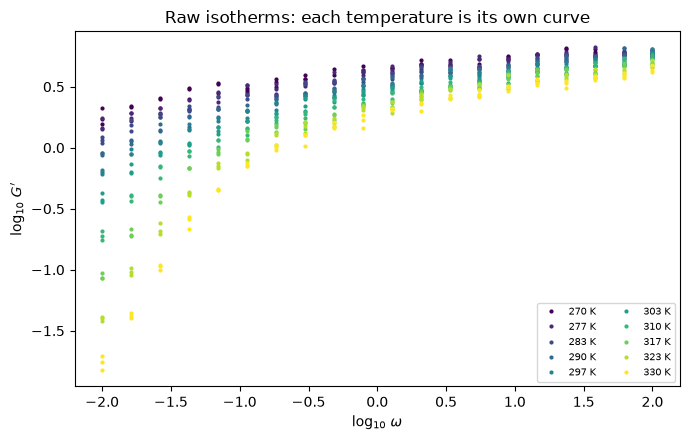

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(temperatures)))
for color, temperature in zip(colors, temperatures):
    mask = data["temperature"] == temperature
    ax.plot(data["log_omega"][mask], data["log_Gp"][mask], ".",
            color=color, ms=4, label=f"{temperature:.0f} K")
ax.set_xlabel(r"$\log_{10}\,\omega$")
ax.set_ylabel(r"$\log_{10}\,G'$")
ax.set_title("Raw isotherms: each temperature is its own curve")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

## 2. Fit

Note what has to be declared rather than guessed:

- **`domain="frequency"`** fixes the sign convention ($z = x + s$). This *names* the
  transform rather than changing it — the collapse is identical either way, so getting
  it wrong flips the sign of every shift factor and of the activation energy while every
  plot still looks perfect.
- **`condition_scale="kelvin"`** declares the condition is an absolute temperature. That
  enables the reciprocal-condition families and rejects a Celsius-looking column.
- The abscissa is **already in log units**. The module does not take logs for you.

`validation="loco"` turns on leave-one-condition-out validation, which is the verdict.

In [3]:
model = SuperpositionRegressor(
    condition="temperature",
    abscissa="log_omega",
    response="log_Gp",
    domain="frequency",
    condition_scale="kelvin",
    reference=T_REF,
    candidate_families=("arrhenius", "wlf", "polynomial"),
    max_terms=2,
    validation="loco",
    max_holdout_conditions=4,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model.fit(data)

print(model.summary())

SuperpositionRegressor
domain            : frequency (z = x + s(c))
reference         : 300
channels          : ['log_Gp']
conditions        : 10

Transform (the identified quantity)
----------------------------------------------
           270  ->  +1.0406
       276.667  ->  +0.7912
       283.333  ->  +0.5528
           290  ->  +0.3245
       296.667  ->  +0.1059
       303.333  ->  -0.1037
           310  ->  -0.3049
       316.667  ->  -0.4982
       323.333  ->  -0.6840
           330  ->  -0.8627
  effective activation energy : 54.2 kJ/mol

Selected law (not the headline -- see shift_expression_ notes)
----------------------------------------------
  s(q) = -10.798*(q/(1.06991*(1.06991 + q)))

Superposition validity
verdict              : supported
noise floor          : 0.03016 (from replicates)
in-sample collapse   : 0.03037
held-out collapse    : 0.03178 (1.05 x noise floor, 4 conditions)
held-out shift error : 0.01625
thresholds           : supported <= 2x, weakly <= 4x noi

## 3. Finding #1 — the transform is identifiable, the equation is not

Compare what was recovered against the truth.

In [4]:
recovered = model.shift_factors(temperatures)
truth = true_log_shift(temperatures)
error = np.abs(recovered - truth)

print(f"{'T (K)':>8} {'recovered':>11} {'true':>9} {'|error|':>9}")
for temperature, got, want, err in zip(temperatures, recovered, truth, error):
    print(f"{temperature:8.1f} {got:11.4f} {want:9.4f} {err:9.4f}")
print(f"\nmedian |error| = {np.median(error):.4f} decades")
print(f"max    |error| = {np.max(error):.4f} decades   (acceptance criterion: 0.15)")

   T (K)   recovered      true   |error|
   270.0      1.0406    1.0814    0.0409
   276.7      0.7912    0.8208    0.0296
   283.3      0.5528    0.5725    0.0198
   290.0      0.3245    0.3356    0.0111
   296.7      0.1059    0.1094    0.0034
   303.3     -0.1037   -0.1070    0.0032
   310.0     -0.3049   -0.3140    0.0090
   316.7     -0.4982   -0.5123    0.0141
   323.3     -0.6840   -0.7024    0.0184
   330.0     -0.8627   -0.8848    0.0221

median |error| = 0.0162 decades
max    |error| = 0.0409 decades   (acceptance criterion: 0.15)


In [5]:
print("Selected law :", model.shift_expression_)
print(f"E_eff        : {model.effective_activation_energy() / 1000:.1f} kJ/mol")
print(f"true E       : {E_TRUE / 1000:.1f} kJ/mol")

Selected law : -10.798*(q/(1.06991*(1.06991 + q)))
E_eff        : 54.2 kJ/mol
true E       : 55.9 kJ/mol


The data was generated from a **pure Arrhenius** law, and the Arrhenius basis
($1/(1+q)^2$) was in the library. Look at which term was actually selected.

Over a realistic 60 K window, $1/(1+q)^2$, $1/(c_2+q)^2$ and low-order polynomials span
nearly the same function space — and Arrhenius *is* the WLF term at $c_2 = 1$. No
information criterion can separate them, so the selected **structure** is close to
arbitrary among near-equivalent forms, while the **transform** it encodes is pinned down.

In the study behind this module only 62% of 90 fits selected the true Arrhenius basis;
the other 38% picked one of nine distinct structural forms — all producing the same
transform to ~0.01 decades.

**So report `shift_factors()` and `effective_activation_energy()`. Do not report
`shift_expression_`.** The effective activation energy is the useful summary precisely
because it is comparable across structurally different fits.

## 4. The collapse

Apply the transform and rebuild the master curve.

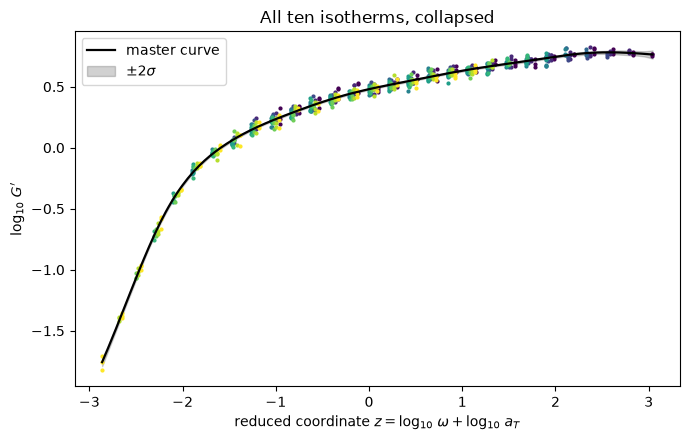

In [6]:
reduced = model.transform()
master = model.master_curve_["log_Gp"]

fig, ax = plt.subplots(figsize=(7, 4.5))
for color, temperature in zip(colors, temperatures):
    mask = reduced["temperature"] == temperature
    ax.plot(reduced["z"][mask], reduced["w"][mask], ".", color=color, ms=4)
ax.plot(master.z, master.y, "k-", lw=1.6, label="master curve")
ax.fill_between(master.z, master.y - 2 * master.std, master.y + 2 * master.std,
                color="k", alpha=0.18, label=r"$\pm 2\sigma$")
ax.set_xlabel(r"reduced coordinate $z = \log_{10}\,\omega + \log_{10}\,a_T$")
ax.set_ylabel(r"$\log_{10}\,G'$")
ax.set_title("All ten isotherms, collapsed")
ax.legend()
fig.tight_layout()

In [7]:
print(f"collapse RMSE : {collapse_rmse(reduced['z'], reduced['w']):.4f}")
print(f"noise floor   : {model.noise_floor_:.4f}  (from {model.noise_floor_source_})")

collapse RMSE : 0.0304
noise floor   : 0.0302  (from replicates)


## 5. Finding #2 — a beautiful collapse proves nothing

Now the important part. We build a **thermorheologically complex** material: two
relaxation groups with *different* activation energies, so no single scalar shift factor
can collapse the family. There is no valid transform, and the honest answer is "this
does not superpose."

In [8]:
taus_fast, taus_slow = np.logspace(-1.5, -0.5, 3), np.logspace(0.5, 1.5, 3)
rng_bad = np.random.RandomState(0)
temps_bad = np.linspace(T_REF - 50, T_REF + 50, 10)

rows_bad = {"temperature": [], "log_omega": [], "log_Gp": []}
for temperature in temps_bad:
    a_fast = float(true_log_shift(temperature, 10e3))     # 10 kJ/mol
    a_slow = float(true_log_shift(temperature, 180e3))    # 180 kJ/mol -- different!
    for _ in range(2):
        w_fast = 10.0 ** (log_omega_grid + a_fast)
        w_slow = 10.0 ** (log_omega_grid + a_slow)
        modulus = sum((w_fast * t) ** 2 / (1 + (w_fast * t) ** 2) for t in taus_fast)
        modulus += sum((w_slow * t) ** 2 / (1 + (w_slow * t) ** 2) for t in taus_slow)
        rows_bad["temperature"].extend([temperature] * log_omega_grid.size)
        rows_bad["log_omega"].extend(log_omega_grid)
        rows_bad["log_Gp"].extend(np.log10(modulus) + rng_bad.normal(0.0, NOISE, log_omega_grid.size))

data_bad = {k: np.asarray(v) for k, v in rows_bad.items()}

model_bad = SuperpositionRegressor(
    condition="temperature", abscissa="log_omega", response="log_Gp",
    domain="frequency", condition_scale="kelvin", reference=T_REF,
    max_terms=2, validation="loco", max_holdout_conditions=3,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_bad.fit(data_bad)

print("It still returns a confident shift law:")
print(" ", model_bad.shift_expression_)

It still returns a confident shift law:
  1321.83*(q**3/3) + -11.4007*(q/(0.620922*(0.620922 + q)))


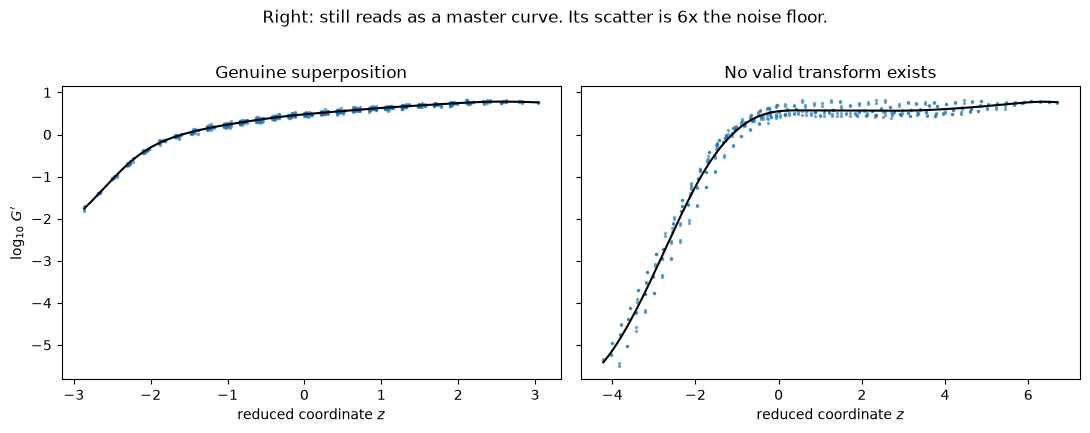

In [9]:
reduced_bad = model_bad.transform()
master_bad = model_bad.master_curve_["log_Gp"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, red, mast, title in (
    (axes[0], reduced, master, "Genuine superposition"),
    (axes[1], reduced_bad, master_bad, "No valid transform exists"),
):
    ax.plot(red["z"], red["w"], ".", ms=3, alpha=0.5, color="tab:blue")
    ax.plot(mast.z, mast.y, "k-", lw=1.5)
    ax.set_xlabel("reduced coordinate $z$")
    ax.set_title(title)
axes[0].set_ylabel(r"$\log_{10}\,G'$")
fig.suptitle("Right: still reads as a master curve. Its scatter is 6x the noise floor.", y=1.02)
fig.tight_layout()

The right panel still reads as *a master curve with some experimental scatter*. On a plot
spanning seven decades of $G'$, a spread of 0.18 is easy to wave through — and that is the
trap: **the eye cannot supply the noise floor.** Those replicates put the measurement
noise at 0.030, so 0.18 is six times larger than anything the data can excuse.

That is the first reason to distrust a visual collapse. The second is that the in-sample
number is computed against a master curve fitted to the very rows being scored, so it
flatters the model. A temperature **withheld from the entire pipeline** does not: it takes
no part in the smoothing or in the discovery, and is shifted by prediction alone.

In [10]:
for label, m in (("genuine ", model), ("complex ", model_bad)):
    r = m.validity_report_
    print(f"{label}: verdict={r.verdict:17s} "
          f"in-sample={r.in_sample_collapse:.4f}  "
          f"held-out={r.holdout_collapse_median:.4f}  "
          f"({r.holdout_ratio_median:.2f}x noise floor)")

genuine : verdict=supported         in-sample=0.0304  held-out=0.0318  (1.05x noise floor)
complex : verdict=not_supported     in-sample=0.1799  held-out=0.2305  (7.91x noise floor)


Both collapses degrade, but the held-out number is the more sensitive test (7.9x against
6.2x in-sample) and the more trustworthy one, for the reason above.

`validity_report_` grades on multiples of the measured noise floor: `<= 2x` supported,
`<= 4x` weakly supported, beyond that not supported. Notice how much work the noise floor
is doing — without replicates to calibrate it, 0.18 is just a number.

In [11]:
print(model_bad.validity_report_.summary())
print()
print("Per-withheld-condition detail (complex case):")
for entry in model_bad.validity_report_.holdout:
    print(f"  T={entry['condition']:6.1f} K  collapse={entry['collapse_rmse']:.4f} "
          f"({entry['ratio']:5.2f}x)  predicted shift={entry['shift_predicted']:+.3f} "
          f"best-aligning={entry['shift_aligned']:+.3f}")

Superposition validity
verdict              : not_supported
noise floor          : 0.02913 (from replicates)
in-sample collapse   : 0.1799
held-out collapse    : 0.2305 (7.91 x noise floor, 3 conditions)
held-out shift error : 0.8025
thresholds           : supported <= 2x, weakly <= 4x noise floor

Per-withheld-condition detail (complex case):
  T= 250.0 K  collapse=0.2305 ( 7.91x)  predicted shift=+9.224 best-aligning=+7.674
  T= 294.4 K  collapse=0.1855 ( 6.37x)  predicted shift=+0.520 best-aligning=+0.790
  T= 350.0 K  collapse=1.1942 (40.99x)  predicted shift=-1.366 best-aligning=-2.169


That last column is a diagnosis, not decoration. Each withheld curve also reports the
shift that *would* have aligned it best:

| `shift_error` | `collapse_rmse` | Meaning |
|---|---|---|
| large | large | the law extrapolated wrongly — more conditions, or a different family |
| small | large | the curve does not collapse under **any** shift — superposition fails |

Here the predicted and best-aligning shifts are close while the collapse is still bad,
which is the second row: no scalar shift factor exists.

## 6. Finding #3 — stability is anti-correlated with validity

The natural intuition is that an unstable selected expression signals trouble. Let's
check it by running an ensemble over both cases, re-running the whole pipeline
(smoother included) per replicate.

In [12]:
ensembles = {}
for label, table in (("genuine", data), ("complex", data_bad)):
    m = SuperpositionRegressor(
        condition="temperature", abscissa="log_omega", response="log_Gp",
        domain="frequency", condition_scale="kelvin", reference=T_REF,
        max_terms=2, validation="none", n_stability=12, random_state=0,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(table)
    ensembles[label] = m.stability_

print(f"{'case':>9} {'distinct structures':>21} {'stability score':>17}")
for label, s in ensembles.items():
    print(f"{label:>9} {s['n_distinct_structures']:>21} {s['stability_score']:>17.2f}")

     case   distinct structures   stability score
  genuine                     3              0.75
  complex                     1              1.00


Read that against the verdicts from section 5. The intuition is backwards: stability
tracks how well-determined the *search* is, not whether the model is *right*. A material
with no shift law can hand you a perfectly reproducible one.

This is why `validity_report_` — not `stability_` — is the module's verdict.

What the ensemble *is* good for is the spread of structure-independent quantities:

In [13]:
energy = ensembles["genuine"]["effective_activation_energy"]
print(f"E_eff over the ensemble : {energy['mean'] / 1000:.1f} +/- {energy['sd'] / 1000:.1f} kJ/mol")
print(f"true                    : {E_TRUE / 1000:.1f} kJ/mol")
print(f"90% interval            : [{energy['q05'] / 1000:.1f}, {energy['q95'] / 1000:.1f}]")

E_eff over the ensemble : 52.8 +/- 1.4 kJ/mol
true                    : 55.9 kJ/mol
90% interval            : [50.3, 54.3]


## 7. The payoff: predicting an unmeasured temperature

Because the shift law is symbolic, it extrapolates. Classic superposition tooling returns
a table of per-curve shift factors and simply cannot answer this.

shift at 305 K : predicted -0.1548, true -0.1596
prediction RMSE   : 0.0044


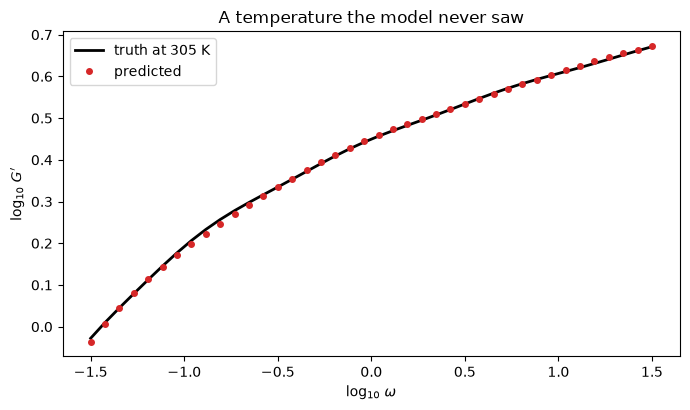

In [14]:
unmeasured = 305.0                        # never in the training data
assert unmeasured not in temperatures

x_new = np.linspace(-1.5, 1.5, 40)
predicted = model.predict(np.full(x_new.size, unmeasured), x_new)
expected = storage_modulus(x_new + true_log_shift(unmeasured))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(x_new, expected, "k-", lw=2, label=f"truth at {unmeasured:.0f} K")
ax.plot(x_new, predicted, "o", ms=4, color="tab:red", label="predicted")
ax.set_xlabel(r"$\log_{10}\,\omega$")
ax.set_ylabel(r"$\log_{10}\,G'$")
ax.set_title("A temperature the model never saw")
ax.legend()
fig.tight_layout()

print(f"shift at {unmeasured:.0f} K : predicted {model.shift_factors([unmeasured])[0]:+.4f}, "
      f"true {true_log_shift(unmeasured):+.4f}")
print(f"prediction RMSE   : {np.sqrt(np.mean((predicted - expected) ** 2)):.4f}")

## Summary

| Question | Answer |
|---|---|
| What is the shift at temperature $T$? | `model.shift_factors(T)` — the identified quantity |
| What is the physics? | `model.effective_activation_energy()` — stable across structures |
| What is the equation? | `model.shift_expression_` — **do not report this** |
| Does the collapse hold? | `model.validity_report_.verdict` — from withheld conditions |
| How reproducible is the search? | `model.stability_` — context, *not* validity |

The one habit worth carrying away: **a collapse you can see is not evidence.** Only a
condition withheld from the whole pipeline is.

### See also

- [Superposition guide](../guides/superposition.md)
- [Structured basis blocks](../guides/structured-blocks.md) — the `Θ(q) ⊙ y_x` machinery underneath
- [Multivariate derivative estimation](../guides/surface-derivatives.md) — the derivative stage
- [Resampling and stability](../guides/resampling.md) — why the ensemble re-runs the smoother